# 05 - Baseline Machine Learning Models

## Objective

Train and evaluate baseline machine learning models on the preprocessed UAV network intrusion dataset.

The purpose of this notebook is to establish benchmark performance before applying feature engineering, hyperparameter tuning, and deep learning models. These baseline results will serve as a reference for evaluating future improvements.

## Workflow

1. Load the preprocessed dataset.
2. Verify dataset dimensions.
3. Train baseline machine learning models.
4. Evaluate each model using multiple performance metrics.
5. Compare the performance of all baseline models.
6. Identify the most promising model for further optimization.

In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [6]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [7]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print()

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (26481, 32)
X_test Shape  : (6621, 32)

y_train Shape : (26481,)
y_test Shape  : (6621,)


## Verify Class Distribution

The class distribution in the training and testing datasets is examined to ensure that stratified sampling has preserved the original distribution of attack classes.

In [8]:
print("Training Set Class Distribution")
display(y_train.value_counts())

print("\nTesting Set Class Distribution")
display(y_test.value_counts())

Training Set Class Distribution


class
1    9604
0    9337
2    7540
Name: count, dtype: int64


Testing Set Class Distribution


class
1    2402
0    2334
2    1885
Name: count, dtype: int64

In [9]:
print("Training Set (%)")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Set (%)")
display((y_test.value_counts(normalize=True) * 100).round(2))

Training Set (%)


class
1    36.27
0    35.26
2    28.47
Name: proportion, dtype: float64


Testing Set (%)


class
1    36.28
0    35.25
2    28.47
Name: proportion, dtype: float64

## Feature Summary

The final feature set used for model training is inspected before fitting the baseline classifiers.

In [10]:
print(f"Total Features : {X_train.shape[1]}")

X_train.columns.tolist()

Total Features : 32


['frame.len',
 'frame.protocols',
 'wlan.duration',
 'wlan.ra',
 'wlan.ta',
 'wlan.da',
 'wlan.sa',
 'wlan.seq',
 'llc.type',
 'ip.hdr_len',
 'ip.len',
 'ip.id',
 'ip.flags',
 'ip.ttl',
 'ip.proto',
 'ip.src',
 'ip.dst',
 'tcp.srcport',
 'tcp.dstport',
 'tcp.seq_raw',
 'tcp.hdr_len',
 'tcp.flags',
 'tcp.window_size',
 'tcp.options',
 'udp.srcport',
 'udp.dstport',
 'udp.length',
 'data.data',
 'data.len',
 'wlan.fc.type',
 'wlan.fc.subtype',
 'time_since_last_packet']

## Baseline Model 1: Logistic Regression

Logistic Regression is used as the first baseline classifier due to its simplicity, interpretability, and efficiency. Although it assumes a linear decision boundary, it provides a strong benchmark against which more complex models can be compared.

In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [12]:
y_pred_lr = lr_model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6371


In [14]:
print("Classification Report\n")

print(classification_report(y_test, y_pred_lr))

Classification Report

              precision    recall  f1-score   support

           0       0.56      0.84      0.67      2334
           1       0.67      0.20      0.30      2402
           2       0.74      0.95      0.83      1885

    accuracy                           0.64      6621
   macro avg       0.66      0.66      0.60      6621
weighted avg       0.65      0.64      0.58      6621



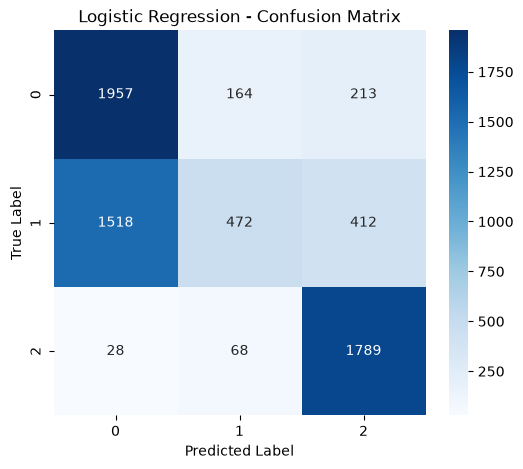

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

### Observation

The Logistic Regression model achieved an overall accuracy of **63.71%** on the test dataset.

Key observations:

- The model performs well in detecting **DoS attacks** with a high recall of **84%**.
- **Benign traffic** is classified very accurately, achieving a recall of **95%**.
- **Replay attacks** are poorly detected, with a recall of only **20%**, indicating that many replay samples are misclassified as DoS attacks.
- The confusion matrix shows significant overlap between Replay and DoS traffic, suggesting that these attack types are difficult to separate using a linear classifier.
- These results indicate that Logistic Regression provides a useful baseline, but more powerful non-linear models are expected to achieve better performance.

## Baseline Model 2: Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions using majority voting.

Unlike Logistic Regression, Random Forest can capture complex non-linear relationships between network traffic features, making it well suited for intrusion detection problems.

The objective of this experiment is to evaluate whether a tree-based model improves the detection of different cyberattacks compared to the Logistic Regression baseline.

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [18]:
y_pred_rf = rf_model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7218


In [20]:
print("Classification Report\n")

print(classification_report(y_test, y_pred_rf))

Classification Report

              precision    recall  f1-score   support

           0       0.67      0.68      0.68      2334
           1       0.66      0.63      0.64      2402
           2       0.85      0.89      0.87      1885

    accuracy                           0.72      6621
   macro avg       0.73      0.73      0.73      6621
weighted avg       0.72      0.72      0.72      6621



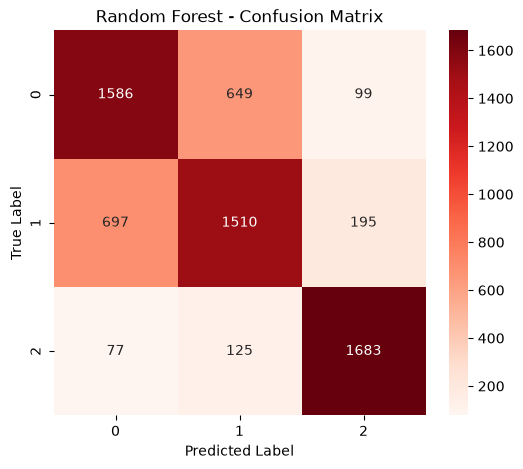

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Observation

Random Forest achieved an accuracy of **72.18%**, improving significantly over the Logistic Regression baseline.

The model produced a more balanced classification performance across all three classes. The most noticeable improvement was observed in the Replay attack class, where the recall increased substantially compared to Logistic Regression.

The confusion matrix indicates that some confusion still exists between DoS and Replay attacks because both attacks share several similar network characteristics. However, the overall number of correctly classified attack samples increased considerably.

These results demonstrate that tree-based ensemble models are more suitable for modeling the complex and non-linear patterns present in UAV network traffic.

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
31,time_since_last_packet,0.289253
7,wlan.seq,0.263562
2,wlan.duration,0.079017
11,ip.id,0.060050
29,wlan.fc.type,0.049653
27,data.data,0.033281
16,ip.dst,0.024135
6,wlan.sa,0.023540
4,wlan.ta,0.022291
3,wlan.ra,0.015656


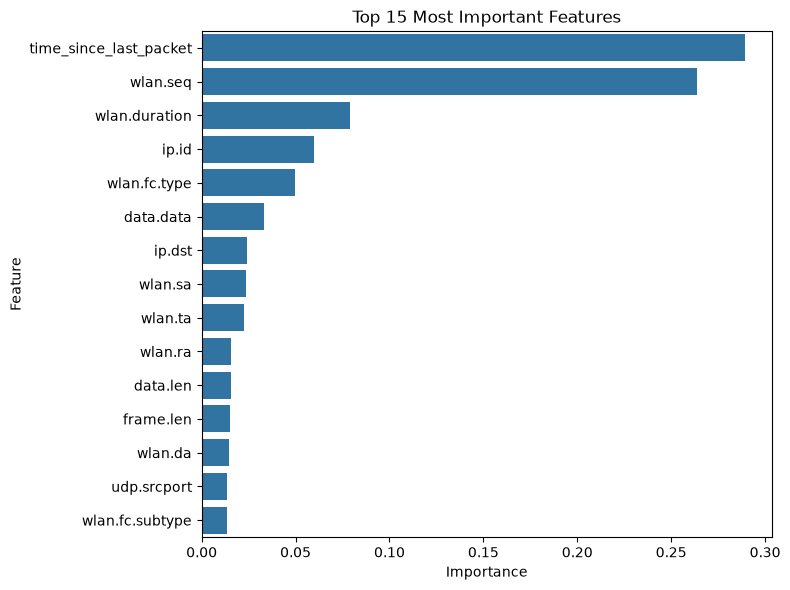

In [26]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")
plt.tight_layout()

plt.show()

### Feature Importance Analysis

Random Forest provides feature importance scores that indicate the contribution of each feature toward intrusion detection.

The analysis shows that **time_since_last_packet** is the most influential feature, followed by **wlan.seq**, **wlan.duration**, and **ip.id**. These features capture important temporal and wireless communication characteristics that differ between benign traffic and cyberattacks.

Interestingly, `wlan.seq`, which was intentionally retained during preprocessing, emerged as one of the most informative features. This validates the preprocessing decision and highlights the importance of protocol-level information for detecting Replay and DoS attacks.

Overall, the feature importance analysis indicates that successful UAV intrusion detection relies on a combination of temporal behavior, wireless communication features, and network-level attributes rather than any single feature.

## Baseline Model 3: XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble boosting algorithm that builds decision trees sequentially, where each new tree learns from the errors made by the previous trees.

Compared to Random Forest, XGBoost generally provides better predictive performance by optimizing the learning process using gradient boosting techniques and regularization.

The objective of this experiment is to evaluate whether boosting-based learning can further improve intrusion detection performance over the previous baseline models.

In [27]:
from xgboost import XGBClassifier

In [28]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,

    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,

    random_state=42,
    eval_metric="mlogloss"
)

In [29]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [30]:
y_pred_xgb = xgb_model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7565


In [32]:
print("Classification Report\n")

print(classification_report(y_test, y_pred_xgb))

Classification Report

              precision    recall  f1-score   support

           0       0.69      0.78      0.73      2334
           1       0.77      0.55      0.64      2402
           2       0.82      0.99      0.90      1885

    accuracy                           0.76      6621
   macro avg       0.76      0.77      0.76      6621
weighted avg       0.76      0.76      0.75      6621



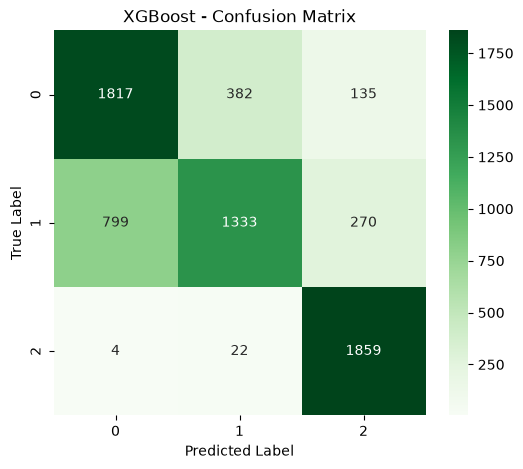

In [33]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
29,wlan.fc.type,0.430149
2,wlan.duration,0.204794
30,wlan.fc.subtype,0.086816
16,ip.dst,0.044400
13,ip.ttl,0.036730
1,frame.protocols,0.024678
4,wlan.ta,0.023186
8,llc.type,0.020875
0,frame.len,0.016765
11,ip.id,0.015627


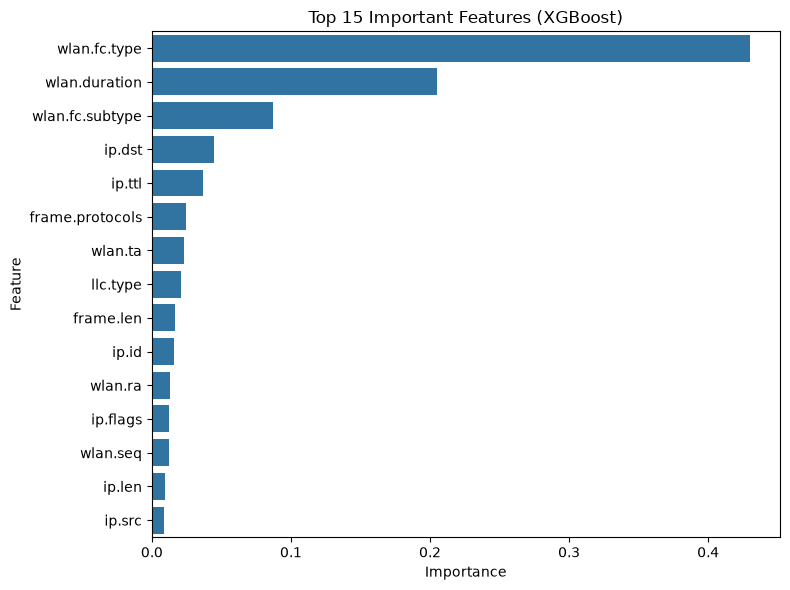

In [35]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features (XGBoost)")
plt.tight_layout()

plt.show()

### Observation

XGBoost achieved the highest performance among all baseline machine learning models, with an accuracy of **75.65%**.

The model produced the best overall balance between precision, recall, and F1-score across the three attack classes. Benign traffic was classified with very high accuracy, while DoS attacks also showed strong detection performance.

Replay attacks remained the most challenging class because their network communication patterns share similarities with normal traffic and DoS attacks. Nevertheless, XGBoost outperformed both Logistic Regression and Random Forest, demonstrating the effectiveness of gradient boosting for learning complex relationships in UAV network traffic.

Based on these results, XGBoost is selected as the strongest baseline model for comparison with the Deep Learning models developed in the next stage of the project.

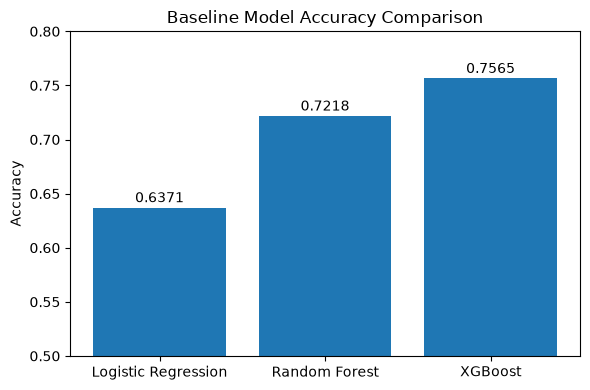

In [36]:
model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [0.6371, 0.7218, 0.7565]

plt.figure(figsize=(6,4))

bars = plt.bar(model_names, accuracies)

plt.title("Baseline Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 0.8)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Final Remarks

In this notebook, three baseline machine learning models were developed and evaluated for UAV network intrusion detection.

The experimental results demonstrate a clear improvement in performance as the model complexity increased from Logistic Regression to Random Forest and finally to XGBoost. Among the evaluated models, XGBoost achieved the highest overall accuracy and the most balanced classification performance across the different attack classes.

These baseline results establish a strong benchmark for the project. In the next notebook, Deep Learning models will be developed and compared against the best-performing machine learning baseline to investigate whether sequential learning can further improve intrusion detection performance.